# Homework 7: Pandas and Seaborn(27 pts)

name: Bryant Willoughby     

email: btwillou@umich.edu

This homework assignment took me 3.5 hours in total to complete. (Please help us to gauge the difficulty of the assignment.)

## Collaboration Disclosure

In the cell below, please list *everyone* with whom you discussed any of the homework problems, excluding only the GSIs and the course instructor. 

If you did not discuss the homework with anyone else, write __"I did not discuss this homework with anyone."__

Even if you discuss questions with other, the code you submit must be only yours. All work is checked with the [MOSS plagiarism detector](https://theory.stanford.edu/~aiken/moss/).

---

## Submission Instructions
Your homework solutions should be written entirely in this Jupyter notebook file. Once it contains your solutions, you should submit this notebook through Canvas. 


Before submitting, please make sure to __Cells->Run All__ executes without errors; errors in your code translate directly to point deductions. 
In general, you don't need to do explicitly raise errors (e.g. with the ```raise``` function) if we don't ask you to in the problem statement.
However, even in cases where we ask you to check for errors, your submission should not contain any examples of your functions actually raising those errors.

Note that many parts of this homework where you are expected to type in code will have ```NotImplementedError()``` as a placeholder. You need to delete this function and replace it with your own code.

## Homework tips 

1. **Start early!** If you run into trouble installing things or importing packages, it’s
best to find those problems well in advance, not the night before your assignment is
due when we cannot help you!

2. **Make sure you back up your work!** At a minimum, do your work in a Dropbox
folder. Better yet, use git, which is well worth your time and effort to learn.

3. **Be careful to follow directions!** Remember that Python is case sensitive. If
you are ask you to define a function called my_function and you define a function
called My_Function, you will not receive full credit. You may want to copy-paste
the function names below to make sure that the functions in your notebook match.

## Error checking

You do not need to do error checking (raising errors, etc.) in your code unless we explicitly ask you to so in a problem.


## Nbgrader

We will be using `nbgrader` to grade your jupyter notebook. You will notice some `read-only` cells in the assignment that contain `assert` statements. These are tests that your code must pass for your solution to be correct. If any of the tests fail, you will get an python error and not get points for that question. 

**Note:** The tests shown not are not comprehensive; additional tests will be used at grading time. You are encouraged to read the problem carefully and verify your code covers all possible cases.

**Be careful:** If a jupyter notebook cell takes longer than `60s` to run, the autograder will not grade it and you will receive zero credit for that question.

# Question 1 (18 pts) 
We will look into the NYC flights dataset using Pandas!

## Question 1.1 (2 pts)
Load the dataset from flights.csv file given with this file into a dataframe variable named `df`

In [1]:
import pandas as pd
df = pd.read_csv("flights.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  object 
 10  flight          336776 non-null  int64  
 11  tailnum         334264 non-null  object 
 12  origin          336776 non-null  object 
 13  dest            336776 non-null  object 
 14  air_time        327346 non-null  float64
 15  distance        336776 non-null  float64
 16  hour            336776 non-null  float64
 17  minute    

In [2]:
assert df is not None
assert isinstance(df, pd.core.frame.DataFrame)

## Question 1.2 (2 pts)
Get the total count of flights for each month and display the top three months with the highest count.

In [3]:
# df.columns
# df.groupby('month').size().sort_values(ascending=False)
monthly_count = df.groupby('month').size().sort_values(ascending=False).head(3)
monthly_count

month
7     29425
8     29327
10    28889
dtype: int64

In [4]:
assert all(monthly_count == pd.Series([29425, 29327, 28889], index = [7, 8, 10]))

## Question 1.3 (2 pts)
First get a new dataframe with the three columns of interest 'carrier', 'month' and 'dep_delay'. Then compute the average dep_delay for each carrier and for each month. Rank the departure delays/month and filter the 1st rank carrier for each month (carrier with the lowest dep_delay for the month will get the 1st rank). Show the results in ascending order of the month

Hint: Some of the functions that can help are rank(), unstack(), stack(). 

In [5]:
# # Mean dep_delay per (month, carrier), pivot, rank per month, select rank 1, sort by month
# df[['carrier', 'month', 'dep_delay']]
# df[['carrier', 'month', 'dep_delay']].groupby(['carrier', 'month'])
# means = df[['carrier', 'month', 'dep_delay']].groupby(['carrier', 'month'])['dep_delay'].mean()
# print(means)
# piv = means.unstack('carrier') # rows = month, cols = carrier
# print(piv.shape); print(piv.iloc[1:5, 1:5])
# ranks = piv.rank(axis=1, method = 'dense', ascending=True)  #rank carriers within each month (1 = smallest mean)
# print(ranks.shape); print(ranks.iloc[1:5, 1:5])
# mask = ranks.eq(1) # get the top rank (lowest delay) for each month
# print(mask.shape); print(mask.iloc[1:5, 1:5])

# # stack back to (month, carrier) Series and keep only rank-1 entries
# avg_delay = piv.stack()[mask.stack()].sort_values('month')
# print(avg_delay)
# avg_delay.columns = ['month', 'carrier', 'dep_delay']
# print(avg_delay)


In [6]:
# Mean dep_delay per (month, carrier), pivot, rank per month, select rank 1, sort by month
means = df[['carrier', 'month', 'dep_delay']].groupby(['month', 'carrier'])['dep_delay'].mean()
piv = means.unstack('carrier')                       # rows = month, cols = carrier
ranks = piv.rank(axis=1, method='dense', ascending=True)  # rank carriers within each month (1 = smallest mean)
mask = ranks.eq(1)        
                          # True where carrier is rank 1 for that month
# stack back to (month, carrier) Series and keep only rank-1 entries
avg_delay = piv.stack()[mask.stack()].reset_index().sort_values('month')
avg_delay.columns = ['month', 'carrier', 'dep_delay']
print(avg_delay)

    month carrier  dep_delay
0       1      VX   1.063492
1       2      AS   0.722222
2       3      HA   1.161290
3       4      HA  -2.100000
4       5      HA  -1.451613
5       6      HA   1.466667
6       7      HA  -1.709677
7       8      HA   1.677419
8       9      HA  -5.440000
9      10      HA  -5.095238
10     11      HA  -5.440000
11     12      HA  -3.142857


In [7]:
# Hidden test here

## Question 1.4 (2 pts)
Find the 5 top destinations in this dataset (most number of flights to). Filter only those flights to these top 5 destinations and then show the distribution of carriers on this filtered data.

In [8]:
# # Top 5 destinations and carrier distribution among those flights
# _top_dest_series = df.groupby('dest').size().sort_values(ascending=False).head(5)
# print(type(_top_dest_series)); print(_top_dest_series)

# # get destination codes (use the Series index, not the values)
# _top_dest = _top_dest_series.index.to_numpy()
# print(type(_top_dest)); print(_top_dest)

# _top = df[df['dest'].isin(_top_dest)]
# print(_top.shape); print(_top.head())
# top_carrier_count = _top.groupby('carrier').size().sort_values(ascending=False)

# # show results
# top_dest, top_carrier_count

In [9]:
# Top 5 destinations and carrier distribution among those flights
_top_dest_series = df.groupby('dest').size().sort_values(ascending=False).head(5)

# get destination codes (use the Series index, not the values)
top_dest = _top_dest_series.index.to_numpy()

# Distribution of carriers for filtered flights
_top = df[df['dest'].isin(top_dest)]
top_carrier_count = _top.groupby('carrier').size().sort_values(ascending=False)

# show results
top_dest, top_carrier_count

(array(['ORD', 'ATL', 'LAX', 'BOS', 'MCO'], dtype=object),
 carrier
 UA    19469
 DL    17707
 B6    13448
 AA    11826
 MQ     4598
 US     4283
 VX     2580
 FL     2337
 9E     2029
 EV     1925
 WN       59
 OO        1
 dtype: int64)

In [10]:
import numpy as np
assert np.all(top_dest == np.array(['ORD', 'ATL', 'LAX', 'BOS', 'MCO']))

## Question 1.5 (2 pts)
Get the total count of cancelled flights in this dataset. We'll say that a cancelled flight has dep_time missing.

In [11]:
# A cancelled flight is one with missing dep_time
cancelled_flight_count = df['dep_time'].isna().sum()
cancelled_flight_count

np.int64(8255)

In [12]:
assert cancelled_flight_count == 8255

## Question 1.6 (2 pts)
Count all the destinations that have a letter 'K' anywhere in the name code.

In [13]:
# Count of flights whose dest contains the letter 'K'
dest_with_k = df['dest'].str.contains('K', na=False).sum()
dest_with_k

np.int64(4589)

In [14]:
assert dest_with_k == 4589

## Question 1.7 (2 pts)
Create a new column called speed that computes the speed as distance/air_time

In [15]:
# Create speed as distance / air_time (miles per minute)
df['speed'] = df['distance'] / df['air_time'] # broadcasting; row-wise division
df['speed']

0         6.167401
1         6.237885
2         6.806250
3         8.612022
4         6.568966
            ...   
336771         NaN
336772         NaN
336773         NaN
336774         NaN
336775         NaN
Name: speed, Length: 336776, dtype: float64

In [16]:
assert type(df['speed']) == pd.Series 
assert abs(df['speed'][0] - 6.1674) < 1

## Question 1.8 (4 pts)
Segment the dep_time 24 hours into 
* night from 12 midnight to 5 am
* morning from 5:01 am to 12 noon
* afternoon from 12.01 noon to 5 pm
* evening from 5.01 pm to 12 am

And then run a query to find the total flights in each segment and save that value in the given variable.


In [17]:
# #note: range: (1, 2400)
# df['dep_time'].dropna().min()
# df['dep_time'].dropna().max()

In [18]:
# Segment dep_time into parts of day using numeric HHMM ranges
# Note: NaNs (cancelled flights) do not count toward any segment
night = (df['dep_time'] >= 0) & (df['dep_time'] <= 500)
morning = (df['dep_time'] >= 501) & (df['dep_time'] <= 1200)
afternoon = (df['dep_time'] >= 1201) & (df['dep_time'] <= 1700)
evening = (df['dep_time'] >= 1701) & (df['dep_time'] <= 2400)

In [19]:
parts_of_day_count = pd.Series({
    'night': night.sum(),
    'morning': morning.sum(),
    'afternoon': afternoon.sum(),
    'evening': evening.sum()
})
parts_of_day_count

night          1487
morning      129939
afternoon     98733
evening       98362
dtype: int64

In [20]:
assert parts_of_day_count['morning'] == 129939
assert parts_of_day_count['evening'] == 98362

# Question 2 (9 pts) 
In this problem, we will do some exploratory data analytics (EDA) by using some of the visualization libraries in Python.

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
airports = pd.read_csv("airports.csv")
print(airports.shape)
print(airports.info())

(1458, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   faa     1458 non-null   object 
 1   name    1458 non-null   object 
 2   lat     1458 non-null   float64
 3   lon     1458 non-null   float64
 4   alt     1458 non-null   int64  
 5   tz      1458 non-null   int64  
 6   dst     1458 non-null   object 
 7   tzone   1455 non-null   object 
 8   state   1453 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 102.6+ KB
None


In [22]:
# Prefer compressed if available
    # note: I am having trouble with compressed file so include this additional check
    # in my wd, I only have flights.csv properly downloaded 
import os

if os.path.exists("flights.csv.gz"):
    flights = pd.read_csv("flights.csv.gz")  # pandas handles gzip automatically
elif os.path.exists("flights.csv"):
    flights = pd.read_csv("flights.csv")
else:
    raise FileNotFoundError("No flights.csv or flights.csv.gz found.")

print(flights.shape)
print(flights.info())

(336776, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  object 
 10  flight          336776 non-null  int64  
 11  tailnum         334264 non-null  object 
 12  origin          336776 non-null  object 
 13  dest            336776 non-null  object 
 14  air_time        327346 non-null  float64
 15  distance        336776 non-null  float64
 16  hour            336776 non-null  float64
 1

## Question 2.1 (3 pts)

Line charts are ideal to show a trend line. Draw a line chart to show monthly frequency count of flights as a trend line for the year 2013. Be sure to choose the correct data to display on the x-axis and y-axis.

In [23]:
# Monthly frequency for 2013
    # sort_index() to ensure months are in order
flights_2013 = flights[flights['year'] == 2013]
monthly = flights_2013.groupby('month').size().sort_index()
print(monthly.shape); print(monthly.head)

(12,)
<bound method NDFrame.head of month
1     27004
2     24951
3     28834
4     28330
5     28796
6     28243
7     29425
8     29327
9     27574
10    28889
11    27268
12    28135
dtype: int64>


In [24]:
# import matplotlib.pyplot as plt
# plt.plot(monthly.index, monthly.values)
# plt.title("Flight Counts for 2013")
# plt.xlabel("Months (1-12)")
# plt.ylabel("Counts")
# plt.show()

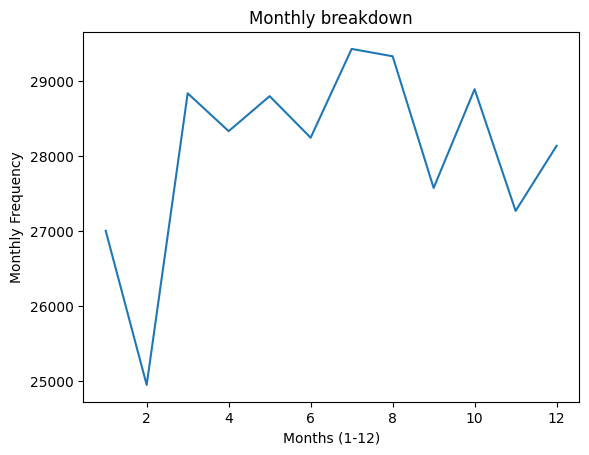

In [25]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly.values)
ax.set_title('Monthly breakdown')
ax.set_xlabel('Months (1-12)')
ax.set_ylabel('Monthly Frequency')

fig1 = ax  # nbgrader expects fig1 to be the Axes

In [26]:
assert fig1.get_title() == 'Monthly breakdown'
assert fig1.get_xlabel() == 'Months (1-12)'
assert fig1.get_ylabel() == 'Monthly Frequency'
assert dict(fig1.lines[0].get_xydata())[6] == 28243

## Question 2.2 (3 pts)
Show the top 5 airports that people flew into using a bar chart. 

In [27]:
# Top 5 arrival airports (dest with most flights) 
counts = flights['dest'].value_counts().head(5); print(counts)

dest
ORD    17283
ATL    17215
LAX    16174
BOS    15508
MCO    14082
Name: count, dtype: int64


In [72]:
# import matplotlib.pyplot as plt
# plt.bar(counts.index, counts.values)
# plt.title("Top 5 Arrival Airports in 2013")
# plt.xlabel("Airport Code")
# plt.ylabel("Number of Flights")

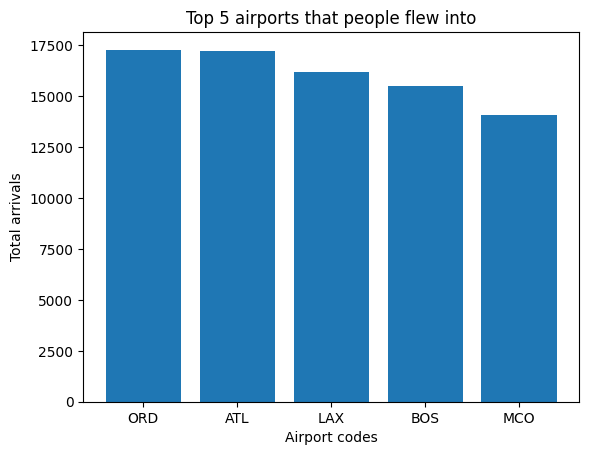

In [28]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.bar(counts.index, counts.values)
ax.set_title('Top 5 airports that people flew into')
ax.set_xlabel('Airport codes')
ax.set_ylabel('Total arrivals')

fig_2 = ax # nbgrader expects fig2 to be the Axes

In [29]:
x_axis = fig_2.get_xaxis()
text1 = x_axis.get_ticklabels()[0]
assert text1.get_text() == 'ORD'
assert fig_2.get_title() == 'Top 5 airports that people flew into'
assert fig_2.get_xlabel() == 'Airport codes'
assert fig_2.get_ylabel() == 'Total arrivals'

## Question 2.3 (3 pts)

Segment the flights based on time-slots with the following criteria
* flights that depart from 00-5:59am as 'red-eye' flights
* flights that depart from 6am - 11:59am as 'morning'
* flights that depart from 12noon - 3:59pm as 'afternoon'
* flights that depart from 4pm - 11:59pm as 'evening' 

And using seaborn create a plot as shown below. PS: Feel free to choose your color palette.

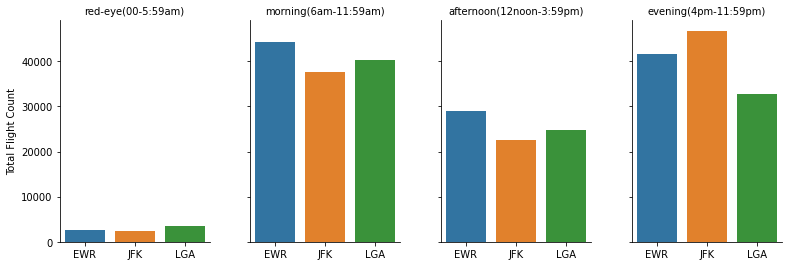

In [30]:
labels = [
    'red-eye(00-5:59am)',
    'morning(6am-11:59am)',
    'afternoon(12noon–3:59pm)',
    'evening(4pm–11:59pm)'
]

# minutes since midnight for non-missing dep_time
_t = flights['dep_time'].dropna().astype(int)
mins = (_t // 100) * 60 + (_t % 100) # convert HHMM to minutes since midnight
slots = pd.cut(mins, bins=[-1, 359, 719, 959, 1439], labels=labels, ordered=True)
print(slots.unique())

# counts per (slot, origin) with explicit 'slot' column to avoid KeyError
origin_order = flights['origin'].value_counts().index.tolist()
counts = (flights.loc[_t.index, ['origin']]
          .assign(slot=slots)
          .groupby(['slot', 'origin'], observed=True)
          .size()
          .reset_index(name='count'))
print(counts.shape); print(counts.head())

['red-eye(00-5:59am)', 'morning(6am-11:59am)', 'afternoon(12noon–3:59pm)', 'evening(4pm–11:59pm)', NaN]
Categories (4, object): ['red-eye(00-5:59am)' < 'morning(6am-11:59am)' < 'afternoon(12noon–3:59pm)' < 'evening(4pm–11:59pm)']
(12, 3)
                   slot origin  count
0    red-eye(00-5:59am)    EWR   2705
1    red-eye(00-5:59am)    JFK   2476
2    red-eye(00-5:59am)    LGA   3549
3  morning(6am-11:59am)    EWR  44306
4  morning(6am-11:59am)    JFK  37666


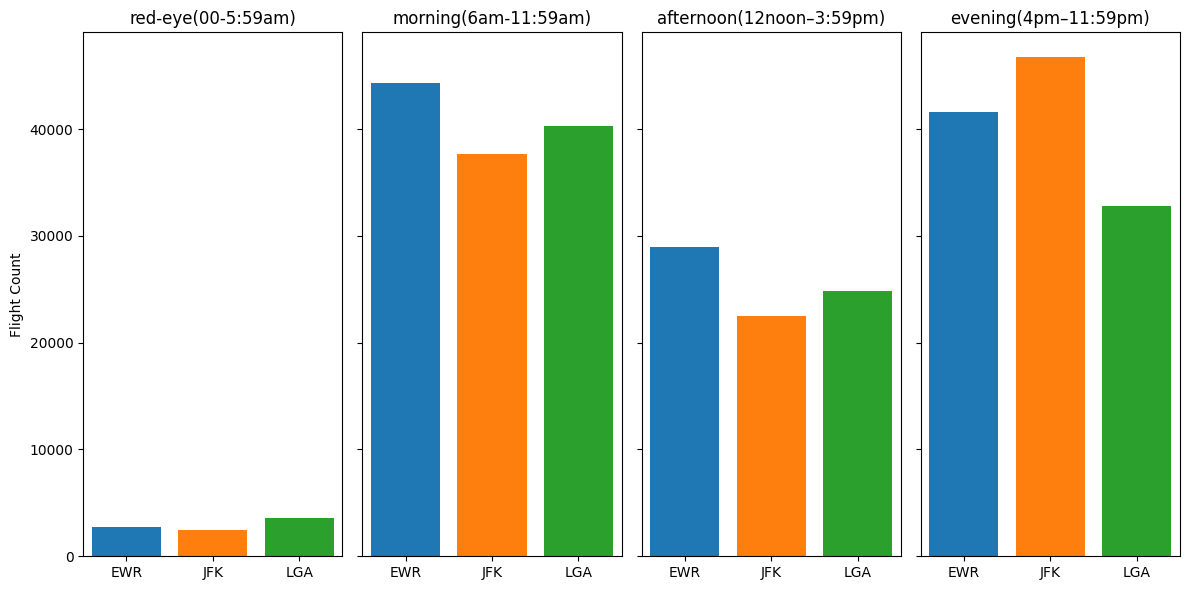

In [31]:
# Concise: minutes -> slots via pd.cut, consistent origin order, four barplots
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# colors for bar 1/2/3 in every subplot
bar_colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(1, 4, figsize=(12, 6), sharey=True)  # same y-axis scale
for ax, lab in zip(axes, labels):
    d = counts[counts['slot'] == lab]
    sns.barplot(data=d, x='origin', y='count', order=origin_order, ax=ax)
    # manual per-axis coloring: first, second, third bars -> blue, orange, green
    for i, bar in enumerate(ax.patches):
        bar.set_facecolor(bar_colors[i % len(bar_colors)])
    ax.set_title(lab)
    ax.set_xlabel('')
    ax.set_ylabel('Flight Count')

for ax in axes[1:]:
    ax.set_ylabel('')

# nbgrader expects fig_3 to be an Axes (first subplot)
fig_3 = axes[0]
plt.tight_layout()
plt.show()

In [32]:
assert fig_3.figure.get_axes()[0].get_title() == 'red-eye(00-5:59am)'
assert fig_3.figure.get_axes()[0].get_ylabel() == 'Flight Count'
assert fig_3.figure.get_axes()[1].get_title() == 'morning(6am-11:59am)'